In [1]:
# Data Analysis
import pandas as pd

import hvplot.pandas

import holoviews as hv

import matplotlib.pyplot as plt

print("Imports successful!")

Imports successful!


In [2]:
# Create an API call to the NOAA NCEI database

ncei_url = ('https://www.ncei.noaa.gov/access/services/data/v1'

           '?dataset=daily-summaries'

           '&dataTypes=TOBS'

           '&stations=USC00052223'

           '&startDate=1997-11-01'

           '&endDate=2026-07-15'

           '&units=standard')

ncei_url

'https://www.ncei.noaa.gov/access/services/data/v1?dataset=daily-summaries&dataTypes=TOBS&stations=USC00052223&startDate=1997-11-01&endDate=2026-07-15&units=standard'

In [4]:
# Open and clean the data

denver_df = pd.read_csv(

    ncei_url,

    na_values=["-99"],

    index_col="DATE",

    parse_dates=["DATE"]

)

denver_df

,STATION,TOBS
DATE,,
1997-11-01,USC00052223,42.0
1997-11-02,USC00052223,38.0
1997-11-03,USC00052223,35.0
1997-11-04,USC00052223,54.0
1997-11-05,USC00052223,34.0
...,...,...
2026-07-11,USC00052223,66.0
2026-07-12,USC00052223,70.0
2026-07-13,USC00052223,70.0


In [5]:
# Keep only the TOBS column

denver_df = denver_df[["TOBS"]]

denver_df.head()

,TOBS
DATE,
1997-11-01,42.0
1997-11-02,38.0
1997-11-03,35.0
1997-11-04,54.0
1997-11-05,34.0


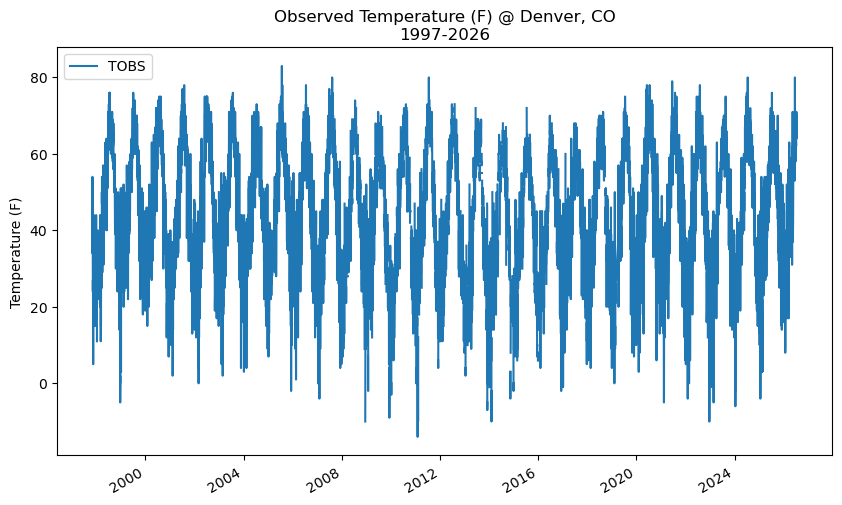

In [6]:
# Plot data with matplotlib

fig, ax = plt.subplots(figsize=(10,6))

denver_df.plot(y='TOBS',

                 ax=ax,

                 ylabel='Temperature (F)',

                 xlabel='',

                 title='Observed Temperature (F) @ Denver, CO\n1997-2026')

plt.show()

In [7]:
# Take the annual mean of the temperature data

ann_climate_df = denver_df.resample('YE').mean()

ann_climate_df

,TOBS
DATE,
1997-12-31,28.295082
1998-12-31,45.082418
1999-12-31,45.432507
2000-12-31,45.278689
2001-12-31,45.164384
2002-12-31,44.647383
2003-12-31,45.778082
2004-12-31,45.435262
2005-12-31,46.927928


<Axes: xlabel='DATE'>

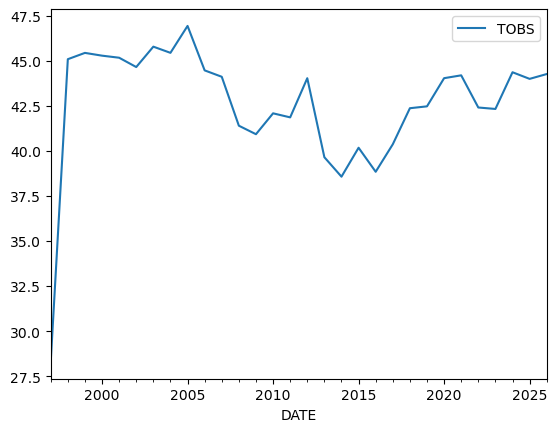

In [8]:
# Plot resampled the data

ann_climate_df.plot()

In [ ]:
# Subset the data to look at last 25 years of data

denver_25yr = ann_climate_df.loc["1999":"2025"]

denver_25yr

,TOBS
DATE,
1999-12-31,45.432507
2000-12-31,45.278689
2001-12-31,45.164384
2002-12-31,44.647383
2003-12-31,45.778082
2004-12-31,45.435262
2005-12-31,46.927928
2006-12-31,44.462604
2007-12-31,44.107872


<Axes: xlabel='DATE'>

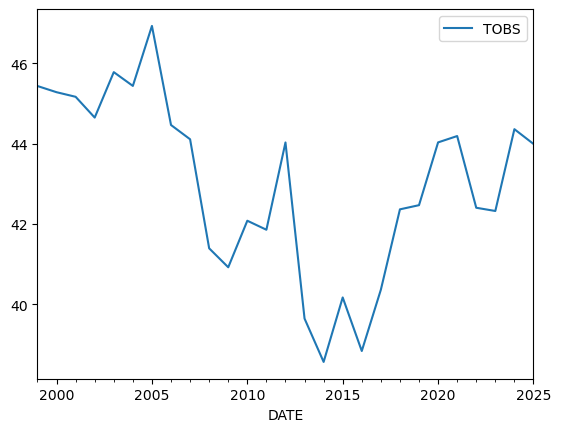

In [13]:
# Plot 25 yrs of data

denver_25yr.plot()

In [15]:
# Create an interactive plot with hvplot

denver_25yr_plot = denver_25yr.hvplot(
    title='Observed Temperature (F) @ Denver, CO\n1999-2025'
)

denver_25yr_plot

:Curve   [DATE]   (TOBS)

In [16]:
# Save interactive plot as html to host on the web

hv.save(denver_25yr_plot, 'denver_plot.html')

